In [9]:
import pickle
import random
import torch
from tqdm import tqdm
from minf.data import FieldDataset
from minf.models import Decoder, SirenNetUnbatched
from minf.utils import plot_field
from minf.metamol import Metamol
from minf.models.utils import get_grid
from torch.utils.data import DataLoader
import numpy as np
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [28]:
resolution = 32

pdb_file = "../data/6ega_protein.pdb"
sdf_file = "../data/6ega_ligand.sdf"

properties = [
    "wigner_seitz_electron_density",
]

mmol, _ = Metamol.from_complex(pdb_file, sdf_file, size=resolution, properties=properties, b=0.25)

[21:55:06] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.


In [29]:
mmol.calculate_field()
vector_field = mmol.to_vector_field()[:, :, :, [0, 1, 9, 11, 12, 18]]

In [30]:
rot=2.9
plot_field(vector_field[:, :, :, 2], cam_rotate=rot, resolution=1024).save("ligand.png")
plot_field(vector_field[:, :, :, 5], cam_rotate=rot, resolution=1024).save("protein.png")

yt : [INFO     ] 2025-02-11 21:55:14,058 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 21:55:14,059 Parameters: domain_dimensions         = [128 128 128]
yt : [INFO     ] 2025-02-11 21:55:14,059 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 21:55:14,060 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 21:55:14,060 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 21:55:14,104 Setting default field to ('gas', 'density')
yt : [WARNING  ] 2025-02-11 21:55:14,110 No previously rendered image found, rendering now.
yt : [INFO     ] 2025-02-11 21:55:14,110 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 21:55:14,111 Creating volume
yt : [INFO     ] 2025-02-11 21:55:14,162 Creating transfer function
yt : [INFO     ] 2025-02-11 21:55:14,162 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.
yt : [INFO     ] 2025-02-11 21:5

In [25]:
net = SirenNetUnbatched(
    dim_in=4,
    dim_hidden=256,
    dim_out=1,
    num_layers=8,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

decoder = Decoder(
    net,
    # output_shape=[resolution, resolution, resolution, 24, 1],
    output_shape=[resolution, resolution, resolution, 6, 1],
    latent_dim=128,
    n_shapes=1
)

decoder.cuda()

optim = torch.optim.Adam(lr=1e-4, params=decoder.parameters())

decoder.load_state_dict(torch.load("reconstruction_model.pt", weights_only=True))
decoder.cuda()

Decoder(
  (net): SirenNetUnbatched(
    (layers): ModuleList(
      (0-7): 8 x Siren(
        (activation): Sine()
      )
    )
    (last_layer): Siren(
      (activation): Identity()
    )
  )
  (modulator): ModulatorUnbatched(
    (layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=128, out_features=256, bias=True)
        (1): ReLU()
      )
      (1-7): 7 x Sequential(
        (0): Linear(in_features=384, out_features=256, bias=True)
        (1): ReLU()
      )
    )
  )
)

In [24]:
min_loss = 9999999
for epoch in (pbar := tqdm(range(20000))):
    loss = decoder(vector_field.cuda(), latent_idx=0)
    optim.zero_grad()
    loss.backward()
    optim.step()
    if loss.item() < min_loss:
        min_loss = loss.item()
        torch.save(decoder.state_dict(), "reconstruction_model.pt")
        
    pbar.set_description(f"Epoch {epoch} (loss: {loss.item()})")
    continue
    
    if epoch % 100 == 0:
        try: 
            reconstructed = decoder.predict(decoder.latents[0].cuda())
            reconstructed = reconstructed.cpu().detach().squeeze(-1)
            plot_field(reconstructed[:, :, :, 0], cam_rotate=rot, resolution=1024).save(f"ligand_{epoch:07d}.png")
            plot_field(reconstructed[:, :, :, 5], cam_rotate=rot, resolution=1024).save(f"protein_{epoch:07d}.png")
        except Exception:
            ...

Epoch 984 (loss: 0.0022992000449448824):   5%|██▉                                                        | 985/20000 [01:49<35:15,  8.99it/s]


KeyboardInterrupt: 

In [26]:
def calculate_psnr(original, compressed):
    original = original.astype(np.float32)
    compressed = compressed.astype(np.float32)
    
    mse = np.mean((original - compressed) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

yt : [INFO     ] 2025-02-11 21:35:25,491 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 21:35:25,491 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 21:35:25,492 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 21:35:25,492 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 21:35:25,493 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 21:35:25,539 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-11 21:35:25,546 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 21:35:25,547 Creating volume
yt : [INFO     ] 2025-02-11 21:35:25,566 Creating transfer function
yt : [INFO     ] 2025-02-11 21:35:25,567 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


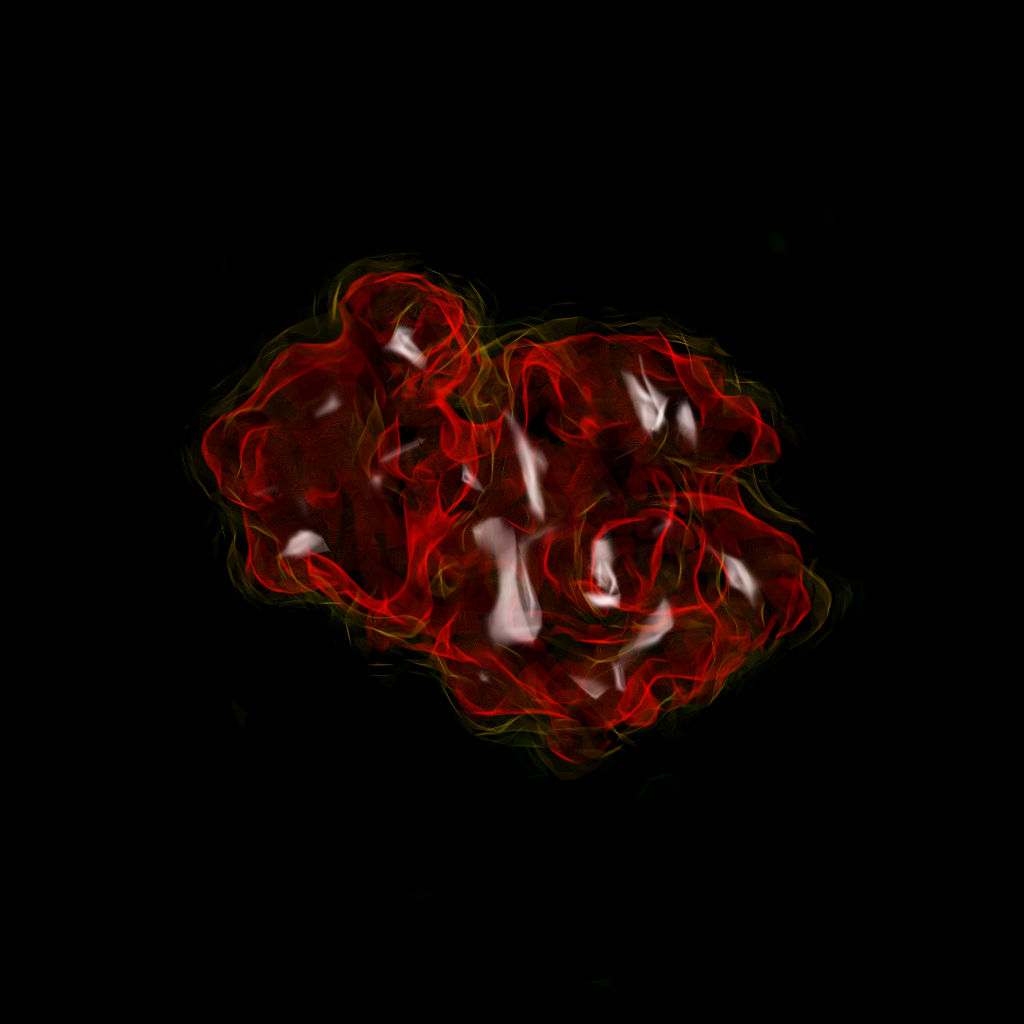

yt : [INFO     ] 2025-02-11 21:35:26,135 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-11 21:35:26,135 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-11 21:35:26,135 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-11 21:35:26,135 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-11 21:35:26,136 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-11 21:35:26,178 Setting default field to ('gas', 'density')
yt : [WARNING  ] 2025-02-11 21:35:26,184 No previously rendered image found, rendering now.
yt : [INFO     ] 2025-02-11 21:35:26,184 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-11 21:35:26,185 Creating volume
yt : [INFO     ] 2025-02-11 21:35:26,201 Creating transfer function
yt : [INFO     ] 2025-02-11 21:35:26,201 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.
yt : [INFO     ] 2025-02-11 21:35:2

np.float32(86.66191)

In [27]:

superres = [32, 32, 32, 6]
coords = get_grid(superres).cuda()

reconstructed = decoder(None, latent_idx=0, coords=coords, output_shape=superres)
#reconstructed = decoder.predict(decoder.latents[0].cuda())
reconstructed = reconstructed.cpu().detach().squeeze(-1)
plot_field(reconstructed[:, :, :, 5], cam_rotate=rot, resolution=1024).show()
plot_field(reconstructed[:, :, :, 2], cam_rotate=rot, resolution=1024).save("ligand.png")

calculate_psnr(vector_field.cpu().detach().numpy(), reconstructed.numpy())